# Curves and Surfaces
Games programming typically includes many objects of various types in game environments. 

In this workbook, we will examine how to construct different types of curves and surfaces using mathematical expressions. We will use the ideas of parameterisation to calculate tangents to curves in 2D and tangent planes and normals to surfaces in 3D.

In [1]:
## Libraries
%matplotlib inline
import numpy as np
import sympy as sym
import math as math
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d import Axes3D, proj3d
from sympy.utilities.lambdify import lambdify, implemented_function

## Parameterisation
Parameterisation is a tool that we can use to simplify the expression of many curves and surfaces.

Mapping curves in 2D requires us to store two positions in Cartesian space: $x$ and $y$. However, curves are continuous: often the $x$ and $y$ positions vary only according to one single parameter. By working with parameters, and knowing that we can convert these back to real space, we can often reduce the complexity of the problem.

Computationally, this is equivalent to using a single function to generate a range of positions on a curve, rather than storing two (possibly large) arrays of $x$ and $y$ positions.

Parameterisation has another advantage: tangents to curves (in 2D) and tangent planes and normals (in 3D) can be easily calculated using the parameterised form of the curve or surface.


### Example: parameterising a circle
Let's say we want to plot the circle $x^2+y^2=4$. 
We need to create, store and plot every pair of positions $(x,y)$ which satisfy this equation.
This will create two arrays of $x$ and $y$ values as seen below:

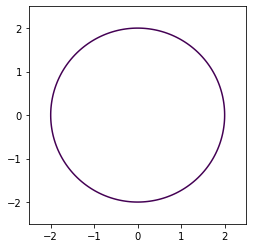

In [2]:
X = np.linspace(-2.5, 2.5, 100)
Y = np.linspace(-2.5, 2.5, 100)
X, Y = np.meshgrid(X,Y)
F = X**2 + Y**2 - 4
fig, ax = plt.subplots(1)
ax.contour(X,Y,F,[0])
ax.set_aspect(1)
plt.show()

This approach is computationally inefficient.

We know from experience that the equation of the circle seen above is satisfied by expressions,

$$
x = 2\cos{(t)},~~~ y = 2\sin{(t)}
$$

Each coordinate, $x$ and $y$, is controlled by a function of a single parameter, which we will call $t$; in this example, this physically is equivalent to an angle. By expressing our coordinates in this way, we have reduced the problem: we now only need to know a range of parameter values, and the functions to relate the parameter back to real space. Computationally, we no longer need to store two position arrays, but now can work out the $x$ and $y$ values based on a single array of angles:

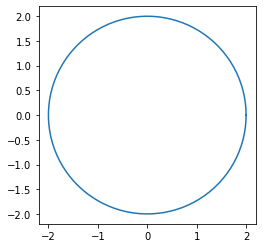

In [3]:
t = np.linspace(0, 2*np.pi, 100)
fig, ax = plt.subplots(1)
ax.plot(2*np.cos(t), 2*np.sin(t))
ax.set_aspect(1)
plt.show()

What is even neater is that this parameterisation allows us to also calculate a tangent to the circle at any given position.

The tangent vector at a given point is determined by the rate of change of the position vector with respect to the parameter.

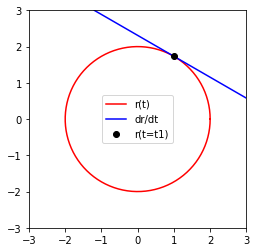

In [30]:
t  = sym.Symbol('t') #parameter
r  = [ 2*sym.cos(t),     2*sym.sin(t)] #position r(t)
dr = [ sym.diff(r[0],t), sym.diff(r[1],t) ] #tangent, dr/dt
# tangent location in parameter space (degrees)
t1 = math.radians(60)

#turn rx and ry into functions to plot them
xf = lambdify(t,r[0])
yf = lambdify(t,r[1])
#specify parameter range
tvals = np.linspace(0, 2*np.pi, 100)
# calculate x and y arrays of positions based on t
xvals = xf(tvals)
yvals = yf(tvals)
#plot
fig, ax = plt.subplots(1)
ax.set_xlim([-3, 3])
ax.set_ylim([-3, 3])
ax.plot(xvals,yvals,'r', label='r(t)')
# location where tangent calculated
xp = float(r[0].subs({t:t1}))
yp = float(r[1].subs({t:t1}))
# to draw tangent line, need gradient
# gradient can be infinite if dx=0
if dr[0].subs({t:t1}) == 0:
    print ('avoiding divide by zero')
    slp = 100
else:
    slp = float(dr[1].subs({t:t1})/dr[0].subs({t:t1}))
#ax.plot(xp,yp,'ro')
ax.axline([xp,yp],slope=slp, c='b', label='dr/dt')
ax.plot(xp,yp,'ko', label='r(t=t1)')
ax.legend(loc="center")
ax.set_aspect(1)

plt.show()    

In the above example, the tangent is calculated by differentiating the position (stored in Python as a 2-element list) with respect to the parameter ''t''. We should be able to do this differentiation stage by hand. Because Python carries out the differentiation, and symbolic computation doesn't marry up well with the plotting functions in Python, this plotting routine looks longer than perhaps it needs to be.

**Challenge: re-run this example for a different value of t1, to see how if the code successfully calculates the tangent (confirm visually)**

The advantage here is that Python can do this for **any** parameterised curve.
Let's prove this by making up a parameterised curve and attempting to evaluate the tangent to the curve at a specific point: 

### Example: tangent to a parabola?
**Determine the unit tangent vector for the curve ${\bf\underline{r}}=(1-u){\bf\underline{i}}+2u^2{\bf\underline{j}}$ at the point $u=1$.**

(note this example is inspired by Tutorial Q1(i) on Curves and Surfaces: Q1(i) is actually a straight line and hence its tangent is a bit boring to pick as an example - feel free to modify this example as you see fit, if you want to check the answer of Q1(i) for yourself!)

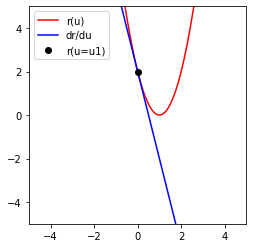

In [39]:
u  = sym.Symbol('u') #parameter
r  = [ 1-u,     2*u**2] #position r(t)
dr = [ sym.diff(r[0],u), sym.diff(r[1],u) ] #tangent, dr/dt
# tangent location in parameter space (degrees)
u1 = 1.0

#turn rx and ry into functions to plot them
xf = lambdify(u,r[0])
yf = lambdify(u,r[1])
#specify parameter range
uvals = np.linspace(-5,5, 100)
# calculate x and y arrays of positions based on t
xvals = xf(uvals)
yvals = yf(uvals)
#plot
fig, ax = plt.subplots(1)
ax.set_xlim([-5, 5])
ax.set_ylim([-5, 5])
ax.plot(xvals,yvals,'r', label='r(u)')
# location where tangent calculated
xp = float(r[0].subs({u:u1}))
yp = float(r[1].subs({u:u1}))
# to draw tangent line, need gradient
# gradient can be infinite if dx=0
if dr[0].subs({u:u1}) == 0:
    print ('avoiding divide by zero')
    slp = 100
else:
    slp = float(dr[1].subs({u:u1})/dr[0].subs({u:u1}))
#ax.plot(xp,yp,'ro')
ax.axline([xp,yp],slope=slp, c='b', label='dr/du')
ax.plot(xp,yp,'ko', label='r(u=u1)')
ax.legend(loc="best")
ax.set_aspect(1)

plt.show() 

As you can see the function is a parabola in $y$, but the derivative of the function always produces the tangent curve which just grazes the curve at the required position.

## 3D objects

In 2D, we have seen that a parameterised curve (which has a position vector as a function of a single parameter) can yield an expression which describes the tangent to the curve (by ordinary differentiation of the function with respect to the parameter).

In 3D, surfaces are commonly described as a function of two parameters (commonly described using the letters $u$ and $v$), and have the form:

$$
{\bf\underline{S}}(u,v)=x(u,v){\bf\underline{i}}+y(u,v){\bf\underline{j}}+z(u,v){\bf\underline{k}}
$$

In the lectures we saw that two tangent vectors are created, by partially differentiating the surface expression with respect to each parameter:

$$
{\bf\underline{t}}_u=\frac{\partial{\bf\underline{S}}}{\partial u}=\frac{\partial x}{\partial u}{\bf\underline{i}}+\frac{\partial y}{\partial u}{\bf\underline{j}}+\frac{\partial z}{\partial u}{\bf\underline{k}},~~~~{\bf\underline{t}}_v=\frac{\partial{\bf\underline{S}}}{\partial v}=\frac{\partial x}{\partial v}{\bf\underline{i}}+\frac{\partial y}{\partial v}{\bf\underline{j}}+\frac{\partial z}{\partial v}{\bf\underline{k}}.
$$

**For a refresher on calculation of partial derivatives, please view the partial derivatives workbook.**

The tangent vectors ${\bf\underline{t}}_u$ and ${\bf\underline{t}}_v$ together define an entire plane:

We can repeat the same process for any object which is fully described by a mathematical equation. Commmon examples include cones and paraboloids. Some of these objects can be difficult to visualise.


## Lecture Example 3: General object
**Find the unit normal at the point where the ray from $(-1,2,0)$ to $(3,1,4)$ cuts the hyperbolic paraboloid $x^2-y^2+4z=0$.**

In [ ]:
r3_o = sym.Matrix([[1, -2, -1]])
r3_e = sym.Matrix([[1, 2, 4]])
t = sym.Symbol('t', positive=True) 
ray3 = r3_o + t * (r3_e - r3_o)
hp = x**2 - y**2 + 4 * z
print(hp)

In [ ]:
sols = sym.solve(hp.subs([(x, ray3[0]), (y, ray3[1]), (z, ray3[2])]),t)
valid_sols = [i for i in sols if i <= 1]
valid_sols.sort()
for i, val in enumerate(valid_sols) :
    print("intersection {} found at t={}".format(i+1,val.evalf()))

In [ ]:
is3  = (ray3.subs(t,valid_sols[0].evalf()))
is3a = np.array(is3.tolist()[0],dtype='float64')
print("intersection occurs at ({:0.3f},{:0.3f},{:0.3f})".format(is3a[0],is3a[1],is3a[2]))

In an ideal world we would visually check that the ray intersects this object: Python isn't great for complex visualisation. One way to check what this object looks like is to use a special library that allows you to examine an isosurface of a 3D function like ours. To do this we may have to install a special library called "plotly".

In [ ]:
from matplotlib import cm
fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(12,6))

X = np.arange(-1, 1, 0.25)
Y = np.arange(-1, 1, 0.25)
X, Y = np.meshgrid(X, Y)
#rearranging the expression to make z the subject:
Z = (X*X-Y*Y)/(-4)
surf = ax.plot_surface(X, Y, Z, rstride=1, cstride=1, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)
ax.set_zlim(-0.51, 0.51)
ax.title.set_text('visualising x^2-y^2+4z=0')
ax.set_xlabel("X Axis")
ax.set_ylabel("Y Axis")
ax.set_zlabel("Z Axis")
fig.colorbar(surf, shrink=0.5, aspect=10)

This function looks like a saddle point: we encountered saddle points when looking at Partial Derivatives (Methods L1). 

Maybe, using your maths skills, you could check whether this is a true saddle point, **using the second derivative test**?

A note of caution: Python can handle some 3D images, but that isn't really what it was made to do. There are other plotting libraries to play with (try "scikit-image" for example), but really you already know about graphics programming in other ways!

## Over to you
Try some more examples from the lectures or the tutorial questions once you are satisfied with the mathematics.